# Plotting tips and tricks

We will use the embryo dataset analysed with the signatures based on the cell segmentation from the {doc}`Celltyping tutorial <celltyping>` as a demonstration.

In [16]:
import pickle

with open("embryo.pickle", "rb") as file:
    embryo = pickle.load(file)

Generally, all plotting functions are available as part of the [`sainsc.LazyKDE`](#sainsc.LazyKDE) object and start with `plot_*`.
They all return a [`matplotlib.Figure`](#matplotlib.figure.Figure) and share a few typical options and parameters including:
- scalebars and zoom options for spatial plots
- removing the background (most plots except the ones based on transcript counts)
- selecting a gene instead of total mRNA for plots that show the KDE

## Plotting genes

As mentioned, genes can be plotted instead of total mRNA.
So instead of ...

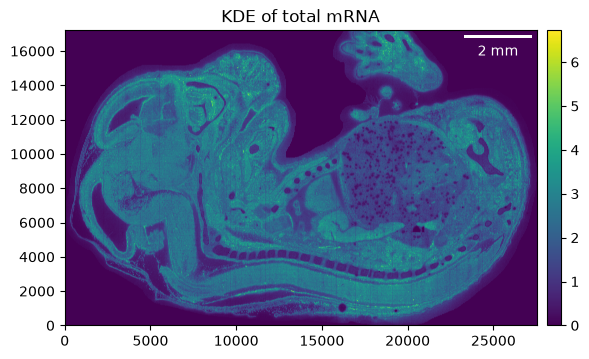

In [17]:
_ = embryo.plot_KDE()

... we can do ... 

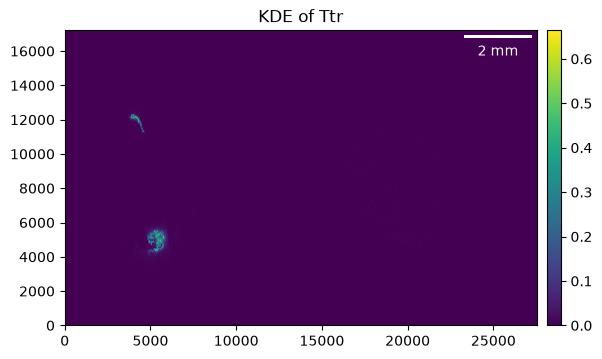

In [18]:
_ = embryo.plot_KDE(gene="Ttr")

## Zoom

Spatial plots allow zooming in by selecting a smaller region, defined by the `crop` parameter as ((x_min, x_max), (y_min, y_max)), to be shown.

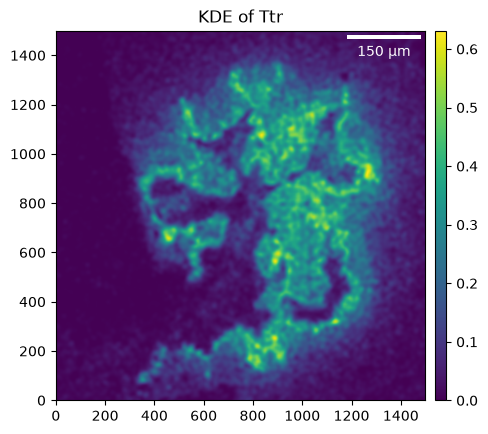

In [19]:
_ = embryo.plot_KDE(gene="Ttr", crop=((4_500, 6_000), (4_200, 5_700)))

## Remove background

Once you have filtered the background, some of the plots allow you to remove the background for 'cleaner' visualizations (actually, the cell-type map is visualized with the background removed by default).

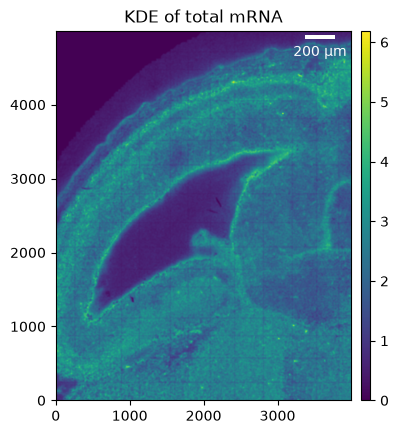

In [34]:
roi = ((2_000, 6_000), (10_000, 15_000))
_ = embryo.plot_KDE(crop=roi)

When removing the background we can see that the low-transcript areas are removed (though the background seems to not be filtered optimally and the threshold likely could be improved).

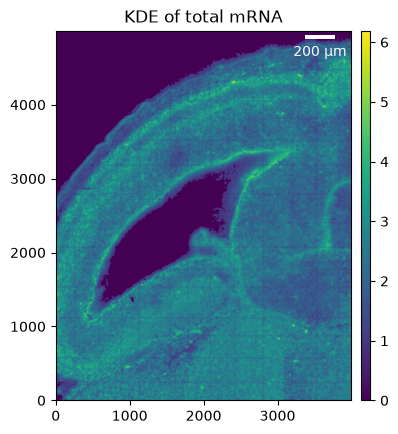

In [35]:
_ = embryo.plot_KDE(crop=roi, remove_background=True)

## Scalebar

The placement and aesthetics of the scale bar can be adjusted as well. 
Refer to the [matplotlib-scalebar](https://github.com/ppinard/matplotlib-scalebar) package for more details.

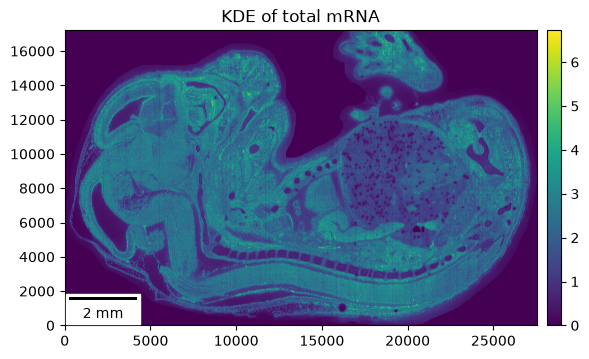

In [20]:
_ = embryo.plot_KDE(scalebar_kwargs={"location": "lower left"})

## Colormaps

Sometimes it is useful to adjust the maximum value or the colormap of the plot.
These parameters can usually be passed to the underlying matplotlib functions.

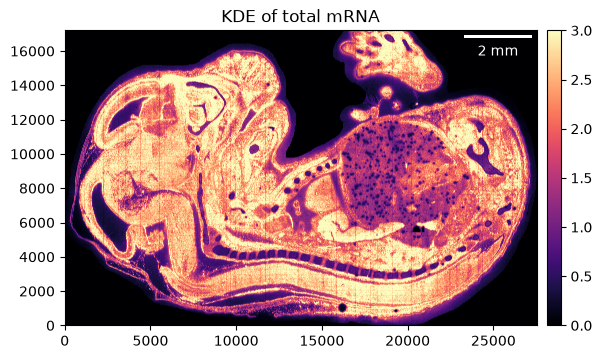

In [21]:
_ = embryo.plot_KDE(im_kwargs={"vmax": 3, "cmap": "magma"})

### Discrete colors for cell types

In contrast to the other plotting functions, the cell-type map is a visualization of discrete labels (rather than continuous values).
You can generate a colormap either automatically by providing a palette that will be used to map the cell types to colors.
Or explicitly by providing a dictionary of cell types and corresponding colors (if the color is a string, it will be converted using [`matplotlib.colors.to_rgb`](#matplotlib.colors.to_rgb)).
Additionally, you can define what the background color is (black by default).

In [25]:
import colorcet as cc

cmap = dict(zip(embryo.celltypes, cc.glasbey))
cmap

{'Cardiomyocyte': '#d60000',
 'Chondrocyte': '#8c3bff',
 'Choroid plexus': '#018700',
 'Dorsal midbrain neuron': '#00acc6',
 'Endothelial cell': '#97ff00',
 'Epithelial cell': '#ff7ed1',
 'Erythrocyte': '#6b004f',
 'Facial fibroblast': '#ffa52f',
 'Fibroblast': '#573b00',
 'Forebrain neuron': '#005659',
 'Forebrain radial glia cell': '#0000dd',
 'Ganglion': '#00fdcf',
 'Hepatocyte': '#a17569',
 'Immune cell': '#bcb6ff',
 'Keratinocyte': '#95b577',
 'Limb fibroblast': '#bf03b8',
 'Macrophage': '#645474',
 'Meninges cell': '#790000',
 'Mid-/hindbrain and spinal cord neuron': '#0774d8',
 'Myoblast': '#fdf490',
 'Olfactory epithelial cell': '#004b00',
 'Radial glia cell': '#8e7900',
 'Smooth muscle cell': '#ff7266',
 'Spinal cord neuron': '#edb8b8',
 'Thalamus neuron': '#5d7e66'}

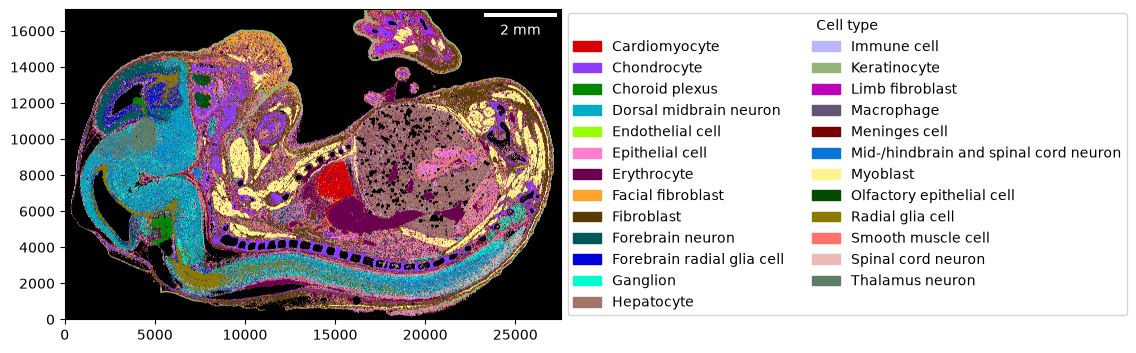

In [26]:
_ = embryo.plot_celltype_map(cmap=cmap)

In the case of providing a color per cell type using a dictionary, you can also define the color to use if a cell type has not been assigned a color (referred to as undefined and grey by default).
This can be useful to highlight one or a few cell types.

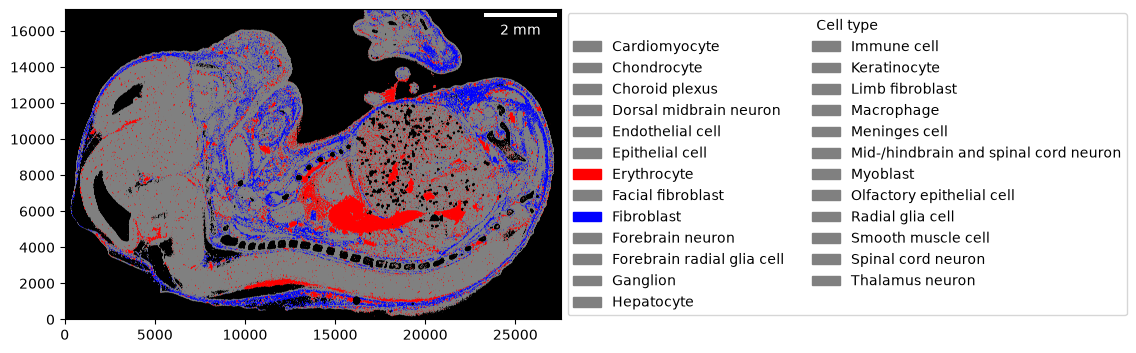

In [27]:
_ = embryo.plot_celltype_map(
    cmap={"Erythrocyte": "red", "Fibroblast": "blue"},
    undefined="grey",
)

The [`sainsc.LazyKDE.plot_celltype_map`](#sainsc.LazyKDE.plot_celltype_map) method also allows returning the celltype map as image rather than plotting it.
This can be useful if you intend to export the full-resolution image, for example.

In [28]:
img = embryo.plot_celltype_map(cmap=cmap, return_img=True)

img.shape

(17204, 27520, 3)